In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

print(nav.head())
print(nav.shape)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
(46000, 3)


In [38]:
plt.savefig("../reports/nav_trend_analysis.png")

<Figure size 640x480 with 0 Axes>

In [39]:
plt.savefig("../reports/nav_trend_analysis.png")

<Figure size 640x480 with 0 Axes>

In [40]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [42]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [43]:
top_aum = aum.groupby('fund_house')['aum_crore'].mean().sort_values(ascending=False)

top_aum.head(10)

fund_house
SBI Mutual Fund             943444.444444
ICICI Prudential MF         699222.222222
HDFC Mutual Fund            636888.888889
Nippon India MF             434333.333333
Kotak Mahindra MF           389111.111111
Aditya Birla Sun Life MF    341888.888889
UTI Mutual Fund             297888.888889
Axis Mutual Fund            280111.111111
Mirae Asset MF              173444.444444
DSP Mutual Fund             156555.555556
Name: aum_crore, dtype: float64

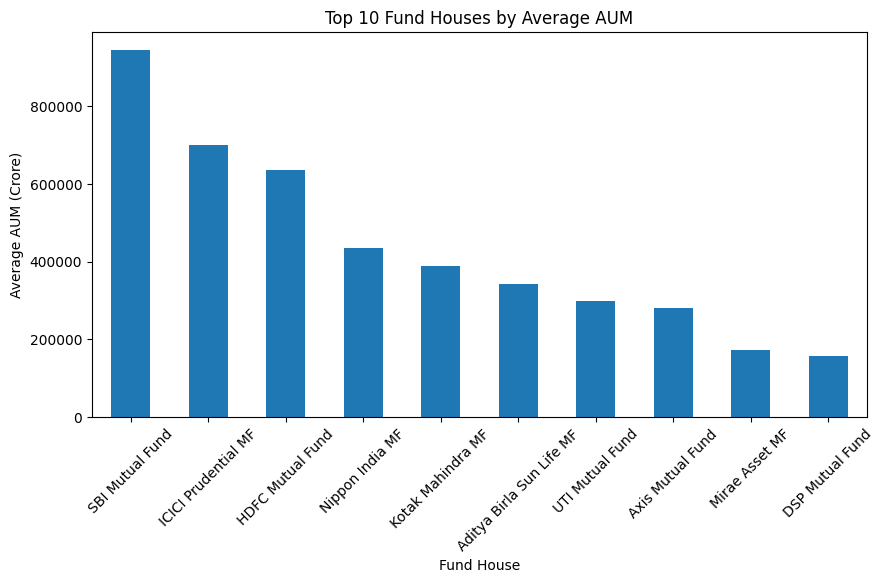

In [44]:
plt.figure(figsize=(10,5))

top_aum.head(10).plot(kind='bar')

plt.title("Top 10 Fund Houses by Average AUM")
plt.xlabel("Fund House")
plt.ylabel("Average AUM (Crore)")

plt.xticks(rotation=45)

plt.show()

In [45]:
import matplotlib.pyplot as plt

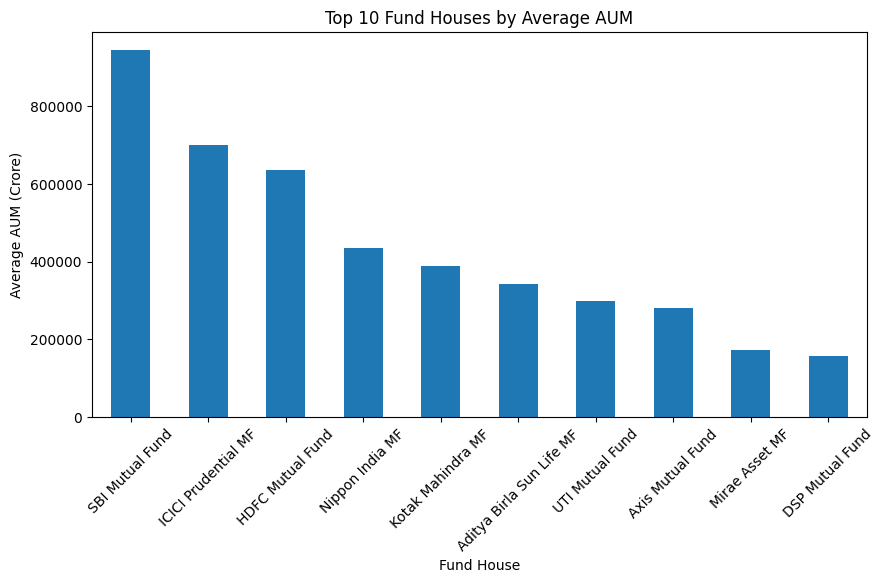

In [46]:
plt.figure(figsize=(10,5))

top_aum.head(10).plot(kind='bar')

plt.title("Top 10 Fund Houses by Average AUM")
plt.xlabel("Fund House")
plt.ylabel("Average AUM (Crore)")

plt.xticks(rotation=45)

plt.show()

In [47]:
plt.savefig("../reports/aum_growth_chart.png")

<Figure size 640x480 with 0 Axes>

In [73]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


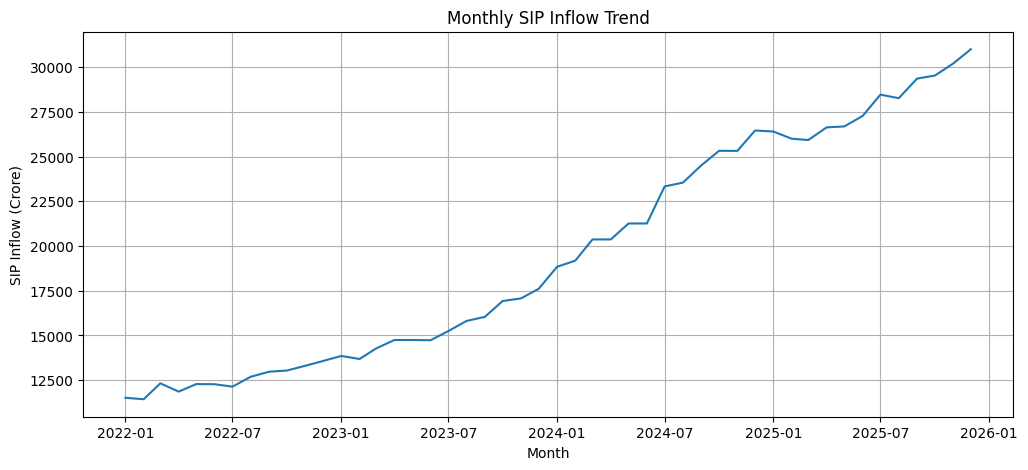

In [49]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(12,5))

plt.plot(sip['month'], sip['sip_inflow_crore'])

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.grid(True)

plt.show()

In [50]:
plt.savefig("../reports/sip_inflow_trend.png")

<Figure size 640x480 with 0 Axes>

In [51]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [52]:
heatmap_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

heatmap_data.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


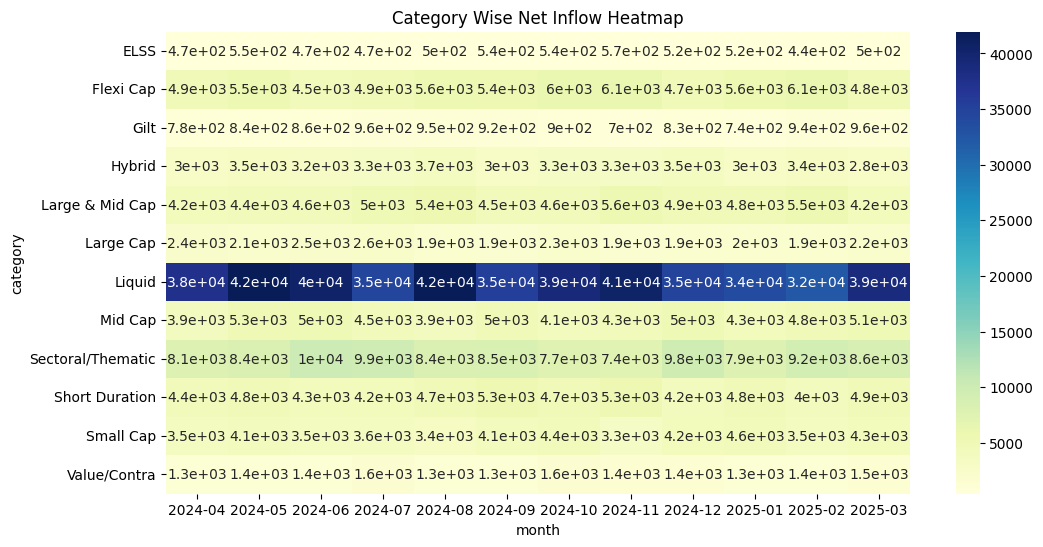

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu")

plt.title("Category Wise Net Inflow Heatmap")

plt.show()

In [54]:
plt.savefig("../reports/category_heatmap.png")

<Figure size 640x480 with 0 Axes>

In [55]:
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


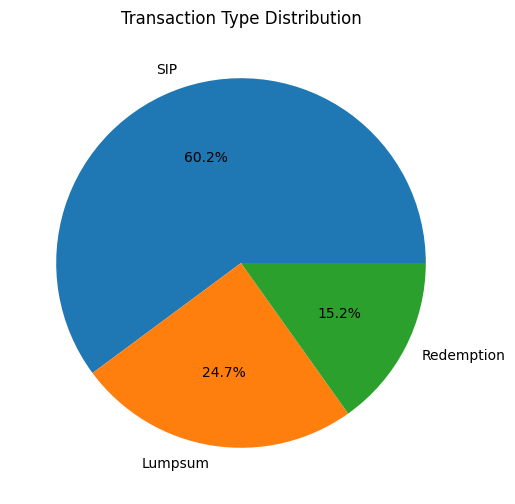

In [56]:
plt.figure(figsize=(6,6))

investor['transaction_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Transaction Type Distribution")
plt.ylabel("")
plt.show()

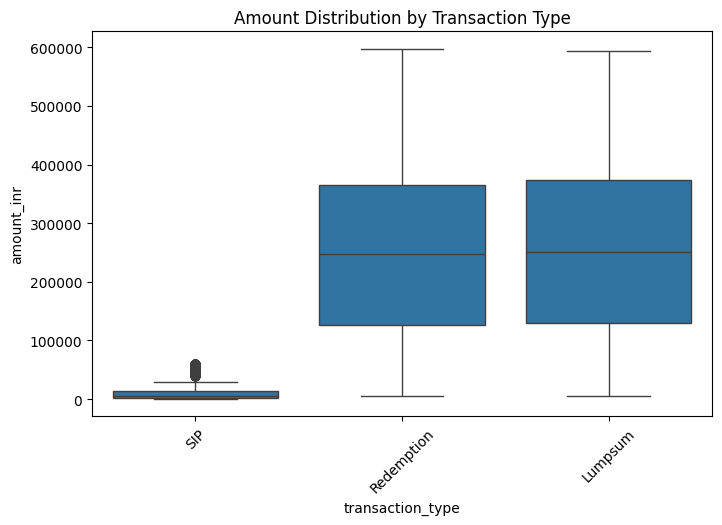

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='transaction_type',
    y='amount_inr',
    data=investor
)

plt.title("Amount Distribution by Transaction Type")
plt.xticks(rotation=45)

plt.show()

In [58]:
plt.savefig("../reports/amount_boxplot.png")

<Figure size 640x480 with 0 Axes>

In [59]:
state_sip = investor.groupby('state')['amount_inr'].sum().sort_values(ascending=False)

state_sip.head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

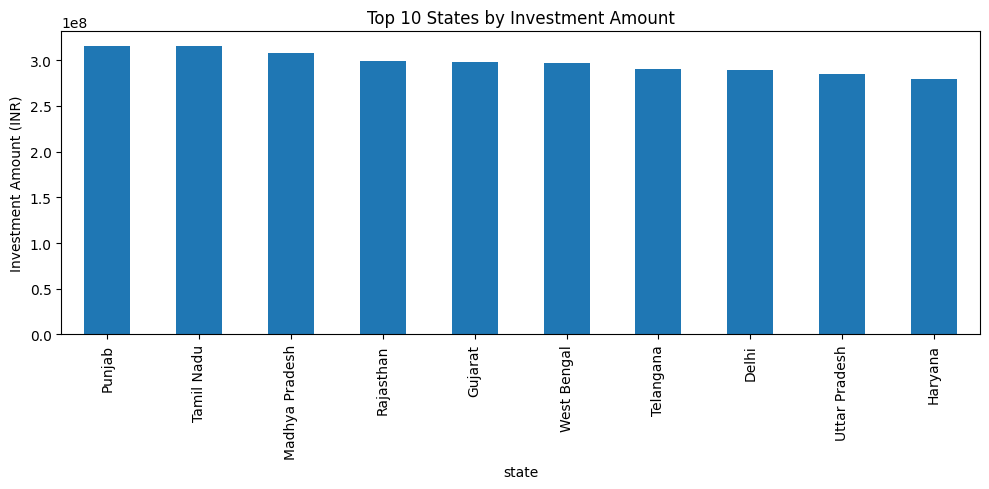

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

state_sip.head(10).plot(kind='bar')

plt.title("Top 10 States by Investment Amount")
plt.ylabel("Investment Amount (INR)")
plt.tight_layout()

plt.savefig("../reports/state_distribution.png")

plt.show()

In [61]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


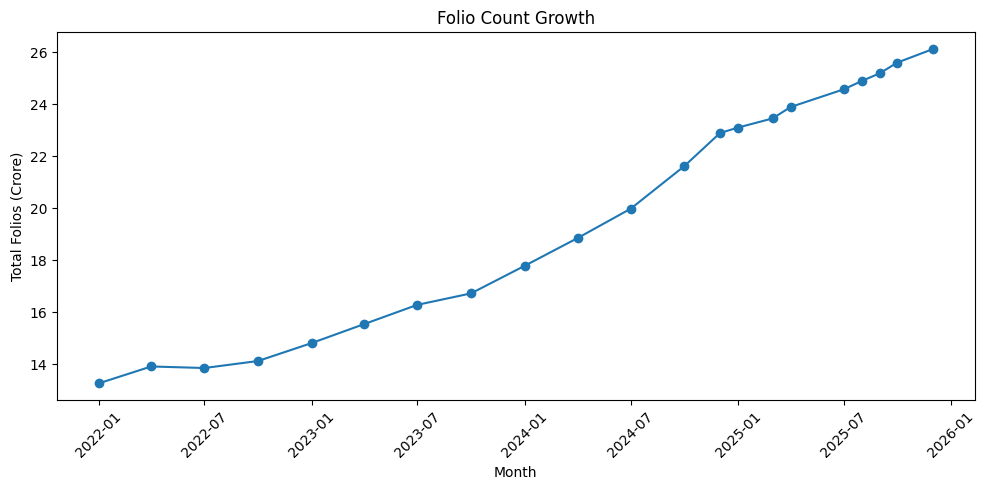

In [62]:
folio['month'] = pd.to_datetime(folio['month'])

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(folio['month'], folio['total_folios_crore'], marker='o')

plt.title("Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../reports/folio_growth.png")

plt.show()

In [63]:
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


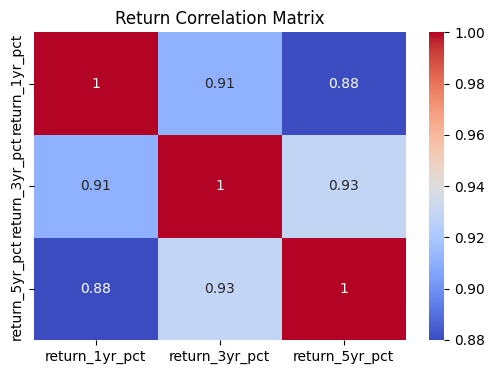

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_data = performance[
    ['return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct']
].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_data,
    annot=True,
    cmap='coolwarm'
)

plt.title("Return Correlation Matrix")

plt.savefig("../reports/correlation_matrix.png")

plt.show()

In [65]:

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


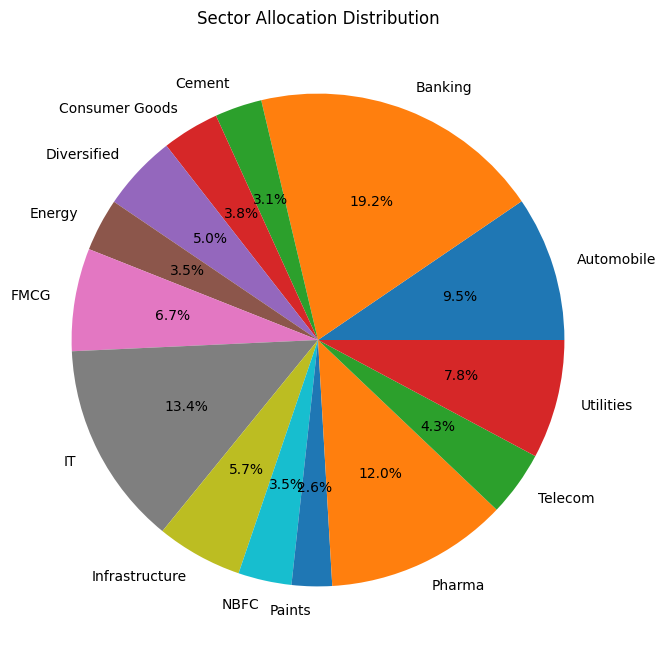

In [66]:
sector_data = holdings.groupby('sector')['weight_pct'].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct='%1.1f%%'
)

plt.title("Sector Allocation Distribution")

plt.savefig("../reports/sector_allocation.png")

plt.show()

# EDA Findings Summary

## Key Insights

1. SBI Mutual Fund has the highest average AUM among fund houses.

2. Monthly SIP inflows showed strong growth from 2022 to 2025.

3. Flexi Cap and Large & Mid Cap categories attracted significant inflows.

4. Folio count increased steadily from 13.26 crore to over 26 crore.

5. Return correlations across 1-year, 3-year and 5-year periods are highly positive.

6. Investor activity is dominated by SIP transactions.

7. Multiple states contribute significantly to mutual fund investments.

8. Portfolio allocations are diversified across sectors such as Banking, Utilities, Pharma and IT.

9. Long-term investor participation has increased consistently.

10. Overall mutual fund industry growth remained strong during the analysis period.

In [67]:
import pandas as pd

In [68]:
import pandas as pd
print("Working")

Working


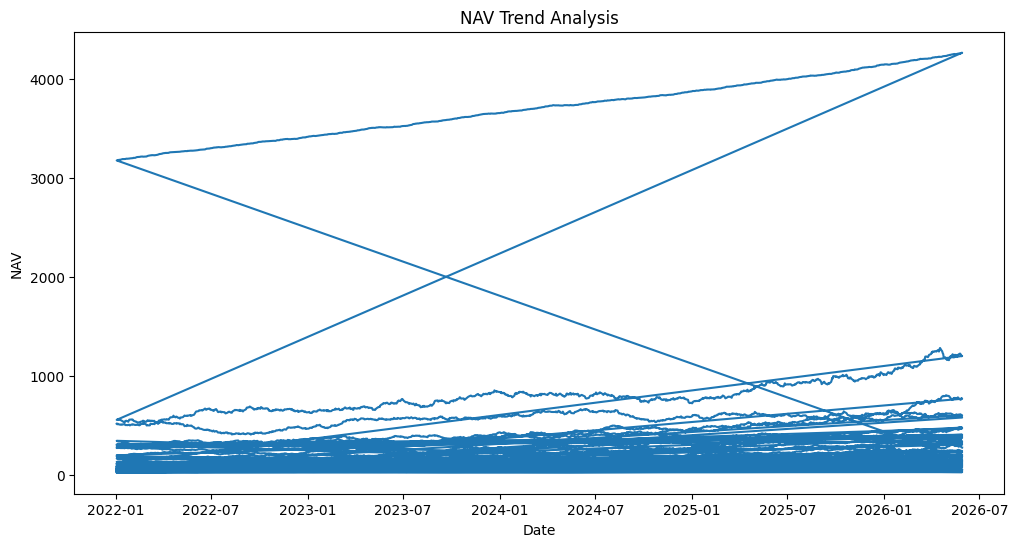

In [69]:
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(12,6))
plt.plot(nav["date"], nav["nav"])

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

In [70]:
nav.describe()

,amfi_code,date,nav
count,46000.000000,46000,46000.000000
mean,120247.000000,2024-03-16 12:00:00,269.570265
min,100016.000000,2022-01-03 00:00:00,26.136600
25%,118632.750000,2023-02-08 00:00:00,69.170425
50%,119551.500000,2024-03-16 12:00:00,122.732150
75%,120842.250000,2025-04-23 00:00:00,260.338675
max,149324.000000,2026-05-29 00:00:00,4268.549700
std,14352.317221,NaN,577.187060


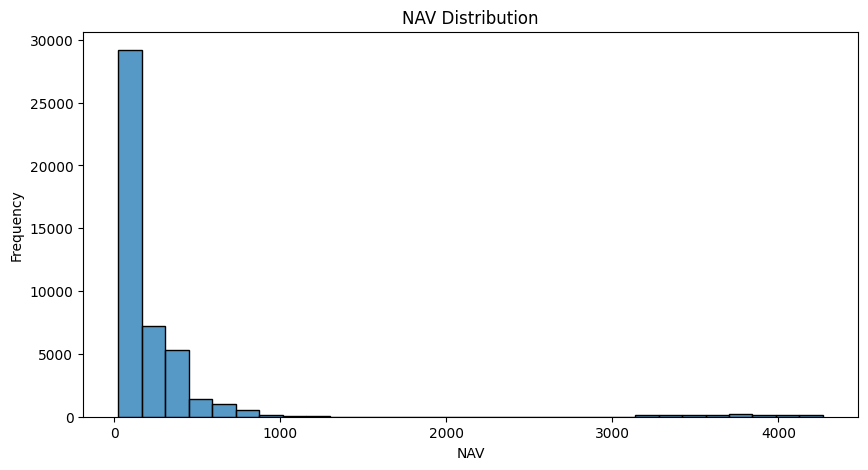

In [71]:
plt.figure(figsize=(10,5))
sns.histplot(nav["nav"], bins=30)

plt.title("NAV Distribution")
plt.xlabel("NAV")
plt.ylabel("Frequency")

plt.show()

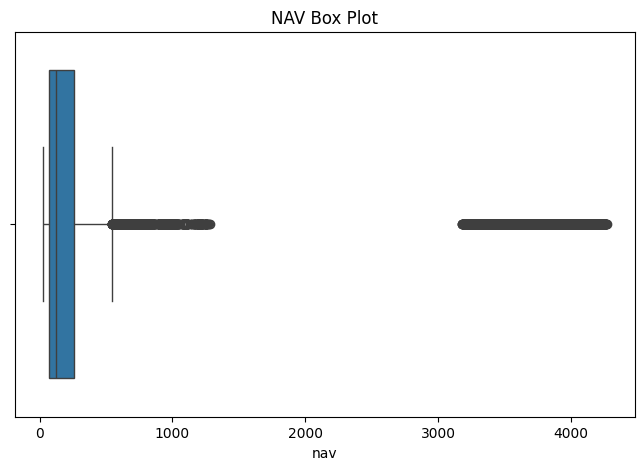

In [72]:
plt.figure(figsize=(8,5))

sns.boxplot(x=nav["nav"])

plt.title("NAV Box Plot")
plt.show()

EDA Findings

1. Dataset contains 46,000 records.
2. Average NAV is 269.57.
3. Minimum NAV is 26.14.
4. Maximum NAV is 4268.55.
5. NAV distribution is right-skewed.
6. Several high-value outliers are present.

# Day 3 EDA Summary

- Loaded and analyzed NAV dataset.
- Created NAV Trend Analysis chart.
- Created NAV Distribution Histogram.
- Created NAV Box Plot.
- Identified dataset statistics and outliers.
- Documented EDA findings.
